# Regressão Linear com PyTorch

## Objetivos

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()

## Importação dos pacotes

In [31]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

## Leitura dos dados

In [32]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [33]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [34]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [35]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)

## Criação do modelo da rede

In [36]:
model = torch.nn.Linear(2, 1, bias=False)

### Verificando a inicialização dos parâmetros

In [37]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight.data

/tmp/ipython-input-1486225639.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


tensor([[-0.0480, -0.0267]])

### Testando o predict da rede

In [38]:
model(Variable(torch.ones((5,2))))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [39]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.3)

### Laço de treinamento

In [40]:
num_epochs = 120
w0_list = []
w1_list = []
for epoch in range(num_epochs):
    inputs = Variable(x_train_bias)
    target = Variable(y_train)

    # forward - predict
    out = model(inputs)

    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    #loss cálculo da função de perda
    loss = criterion(out, target)

    # backward e otimizador
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.item()))

Epoch[20/120], loss: 0.024990
Epoch[40/120], loss: 0.022381
Epoch[60/120], loss: 0.021554
Epoch[80/120], loss: 0.021291
Epoch[100/120], loss: 0.021208
Epoch[120/120], loss: 0.021182


## Avaliação

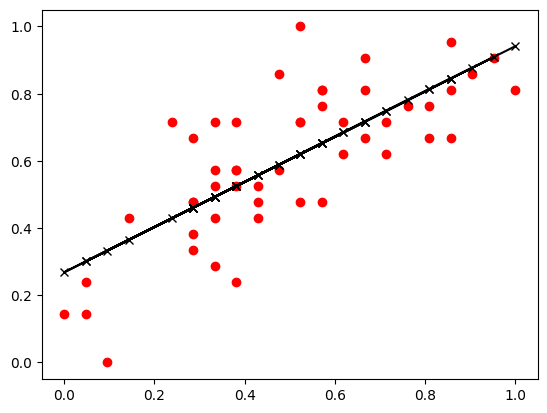

In [41]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

In [42]:
y_pred = model(Variable(x_train_bias))
loss = criterion(y_pred, Variable(y_train))
print(f'Final MSE Loss: {loss.item():.6f}')

Final MSE Loss: 0.021181


# Exercícios

- 1) Calcule o valor da função de custo (MSE) depois da rede treinada, utilizando a
   função `criterion` utilizada no laço de treinamento.

In [43]:
y_pred = model(Variable(x_train_bias))
loss = criterion(y_pred, Variable(y_train))
print(f'Final MSE Loss: {loss.item():.6f}')

Final MSE Loss: 0.021181


- 2) Faça igual o exercício do notebook anterior, de plotar um gráfico scatterplot para
   mostrar a evolução dos parâmetros durante o treinamento pelo gradiente descendente.

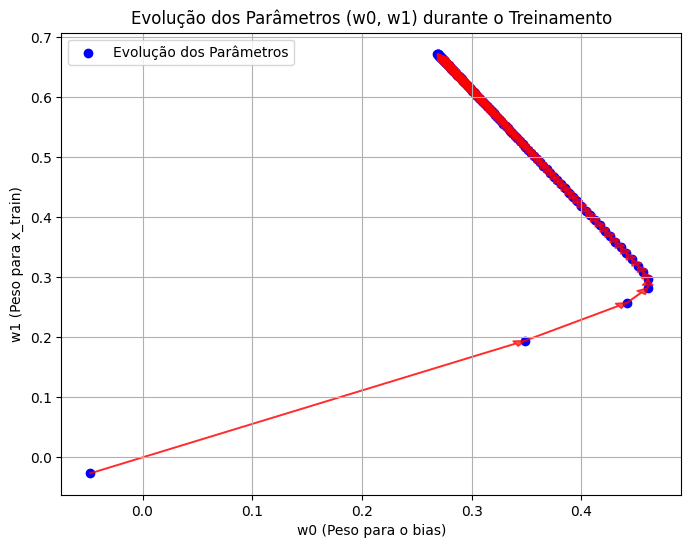

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(w0_list, w1_list, color='blue', label='Evolução dos Parâmetros')
plt.xlabel('w0 (Peso para o bias)')
plt.ylabel('w1 (Peso para x_train)')
plt.title('Evolução dos Parâmetros (w0, w1) durante o Treinamento')

w0_old = None
w1_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True, color='red', alpha=0.7)
    w0_old,w1_old = w0,w1

plt.grid(True)
plt.legend()
plt.show()

- 3) Procure sobrepor a função de perda neste gráfico. (exercício mais difícil).

### Resposta ao Exercício 3:

Para sobrepor a função de perda no gráfico de evolução dos parâmetros, vamos primeiro definir uma função para calcular a perda MSE dado `w0` e `w1`. Em seguida, geraremos um grid de valores para `w0` e `w1`, calcularemos a perda para cada ponto neste grid e, finalmente, plotaremos a superfície de perda como um gráfico de contorno, com o caminho de otimização (a evolução de `w0_list` e `w1_list`) sobreposto.

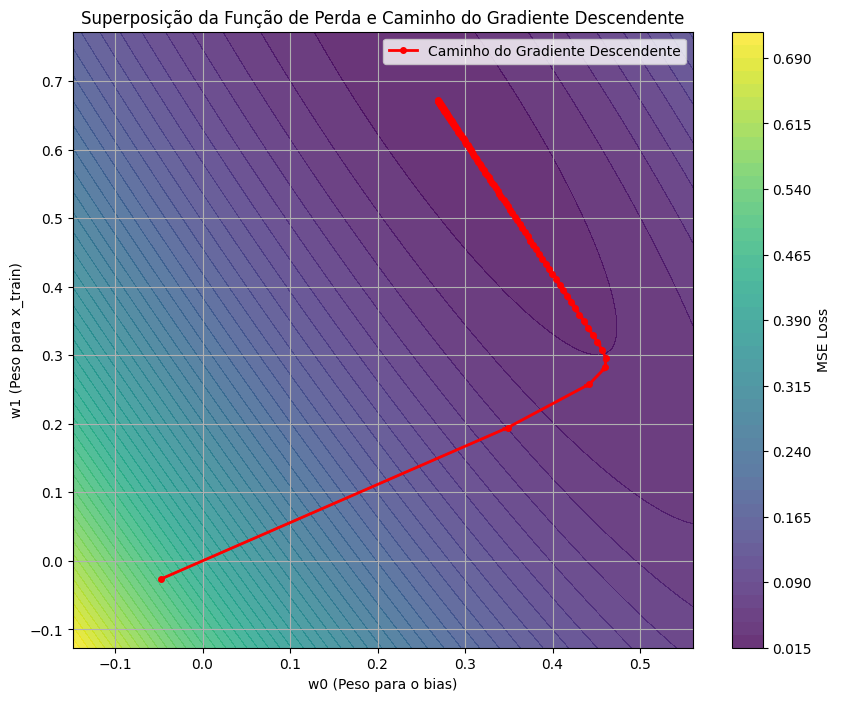

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def compute_loss_surface(w0_val, w1_val, x_bias, y_target, criterion_func):
    # Simulate the model's output for given w0 and w1
    # Note: x_bias[:,0] is the bias (ones), x_bias[:,1] is the actual feature
    predictions = w0_val * x_bias[:, 0].unsqueeze(1) + w1_val * x_bias[:, 1].unsqueeze(1)
    loss = criterion_func(predictions, y_target)
    return loss.item()

# Criar um grid de valores para w0 e w1 ao redor dos valores treinados
w0_min, w0_max = min(w0_list) - 0.1, max(w0_list) + 0.1
w1_min, w1_max = min(w1_list) - 0.1, max(w1_list) + 0.1

W0_grid = np.linspace(w0_min, w0_max, 100)
W1_grid = np.linspace(w1_min, w1_max, 100)
WW0, WW1 = np.meshgrid(W0_grid, W1_grid)

# Certifique-se de que x_train_bias e y_train são tensores PyTorch
x_train_bias_tensor = x_train_bias # Já é um tensor PyTorch do código anterior
y_train_tensor = y_train # Já é um tensor PyTorch do código anterior

# Calcular a perda para cada ponto no grid
Z = np.array([[compute_loss_surface(torch.tensor(w0_i), torch.tensor(w1_j), x_train_bias_tensor, y_train_tensor, criterion) for w0_i in W0_grid] for w1_j in W1_grid])

# Plotar a superfície de perda e o caminho do gradiente descendente
plt.figure(figsize=(10, 8))
contour = plt.contourf(WW0, WW1, Z, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='MSE Loss')

# Plotar o caminho dos parâmetros
plt.plot(w0_list, w1_list, color='red', linestyle='-', linewidth=2, marker='o', markersize=4, label='Caminho do Gradiente Descendente')

# Adicionar setas para indicar a direção da evolução
w0_old = None
w1_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.005,head_width=0.005,shape='full',
                  length_includes_head=True, color='red', alpha=0.7)
    w0_old,w1_old = w0,w1

plt.xlabel('w0 (Peso para o bias)')
plt.ylabel('w1 (Peso para x_train)')
plt.title('Superposição da Função de Perda e Caminho do Gradiente Descendente')
plt.legend()
plt.grid(True)
plt.show()

# Aprendizados